# Cross-Manipulation Generalization Evaluation

This notebook combines the result from all models. We take all five trained models (Xception, EfficientNet-B3, CNN+LSTM, ViT-Base/16, and our proposed Hybrid CNN-Transformer) and evaluate them on **FaceShifter**, which is a manipulation type that none of them has seen during training.

This is a much harder test than the in-domain test split, because it asks: *does the model actually learn what makes a face manipulated, or did it just memorize the artifacts of the four training manipulations?*

**Evaluation setup.** FaceShifter is 100% fake, so AUC is not defined on FaceShifter alone (only one class present). To get a proper AUC we combine the 400 FaceShifter clips with the **real** clips from the in-domain test split, and treat the combination as a single "cross-manipulation evaluation set".

### To view TensorBoard
This notebook only does evaluation. So, no TensorBoard logs here. If you want to inspect training curves of any of the five models, run:
```powershell
tensorboard --logdir ./results
```
Open http://localhost:6006 in your browser.


## 1. Setup

In [1]:
# Import nercessary libraries and the shared utilities
import json
from pathlib import Path
import random
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import models
import timm

# Import shared utilities
from utils import (
    PREPROCESSED_TENSORS_DIR_PATH,
    RESULTS_DIR_PATH,
    DeepfakeClipDataset,
    evaluate,
    load_checkpoint,
    compute_metrics,
)

In [2]:
# Set the seed value
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
# Enable cuDNN auto-tuner to select the fastest convolution algorithms
torch.backends.cudnn.benchmark = True

In [3]:
# Set the device
if torch.cuda.is_available():
    DEVICE = "cuda"
    print(f"GPU Name is:{torch.cuda.get_device_name(0)}")
else:
    DEVICE = "cpu"
    print("Running on CPU. This evaluation will be slow.")

GPU Name is:NVIDIA GeForce RTX 5080


In [4]:
# Set the output paths
output_dir_path = RESULTS_DIR_PATH / "cross_manipulation"
output_dir_path.mkdir(parents=True, exist_ok=True)
print(f"Outputs will be saved to: {output_dir_path.resolve()}")

Outputs will be saved to: C:\x-ion\TEST\results\cross_manipulation


## 2. Build the cross-manipulation evaluation set

We combine the held-out FaceShifter clips (label = 1, fake) with the **real** clips from the in-domain test split (label = 0, real). The result is a single binary dataset on which AUC is well-defined.

We don't shuffle anything. We just build the two splits and combine them at evaluation time using two `DataLoader` and concatenate the predictions.

In [5]:
# Load FaceShifter (held-out manipulation, never seen during training)
splits_json_path = PREPROCESSED_TENSORS_DIR_PATH / "splits.json"
assert splits_json_path.exists(), f"Missing {splits_json_path}."

faceshifter_dataset = DeepfakeClipDataset(
    splits_json_path, "heldout", PREPROCESSED_TENSORS_DIR_PATH, training_augment=False
)

# Load the in-domain test split. We only want the REAL clips from it.
test_dataset_full = DeepfakeClipDataset(
    splits_json_path, "test", PREPROCESSED_TENSORS_DIR_PATH, training_augment=False
)

# Filter test split to keep only the real clips (class_name == "original")
real_test_samples = [s for s in test_dataset_full.samples if s["label"] == 0]
print(f"FaceShifter clips (all fake): {len(faceshifter_dataset)}")
print(f"Real clips from test split:   {len(real_test_samples)}")

FaceShifter clips (all fake): 400
Real clips from test split:   70


In [6]:
# Build a small wrapper dataset for just the real test clips.
# We can't pass a list of samples directly to DeepfakeClipDataset (it loads from splits.json), 
# so we'll mutate a fresh copy's samples list. A bit hacky but keeps the code path simple.
real_only_dataset = DeepfakeClipDataset(
    splits_json_path, "test", PREPROCESSED_TENSORS_DIR_PATH, training_augment=False
)
real_only_dataset.samples = real_test_samples
print(f"Real-only dataset size: {len(real_only_dataset)}")

Real-only dataset size: 70


In [7]:
# confirm the labels are what we expect
faceshifter_labels = [s["label"] for s in faceshifter_dataset.samples]
real_labels = [s["label"] for s in real_only_dataset.samples]

print(f"FaceShifter unique labels: {set(faceshifter_labels)}  (should be {{1}})")
print(f"Real-only unique labels: {set(real_labels)}  (should be {{0}})")
print(f"Total combined evaluation set: {len(faceshifter_dataset) + len(real_only_dataset)} clips")

FaceShifter unique labels: {1}  (should be {1})
Real-only unique labels: {0}  (should be {0})
Total combined evaluation set: 470 clips


## 3. Helper to evaluate one model on the combined set

We need to run the model on both `faceshifter_dataset` and `real_only_dataset`, concatenate the predictions, and compute metrics on the combined predictions. We can't just use `ConcatDataset` and then feed to `evaluate` because we want a clean separation in case we ever want per-source breakdowns later.

In [8]:
@torch.no_grad()
def evaluate_on_combined_set(model, faceshifter_loader, real_loader, device):
    """
    This function runs model on both loaders, returns combined metrics and per-sample predictions.
    """
    model.eval()
    loss_function = nn.BCEWithLogitsLoss()
    
    # Evaluate on FaceShifter clips (all fake)
    _, _, faceshifter_predictions = evaluate(model, faceshifter_loader, loss_function, device)
    # Evaluate on real test clips
    _, _, real_predictions = evaluate(model, real_loader, loss_function, device)
    
    # Concatenate everything
    all_true_labels = faceshifter_predictions["true_labels"] + real_predictions["true_labels"]
    all_predicted_probs = faceshifter_predictions["predicted_probs"] + real_predictions["predicted_probs"]
    all_class_names = faceshifter_predictions["class_names"] + real_predictions["class_names"]
    
    combined_metrics = compute_metrics(all_true_labels, all_predicted_probs)
    
    combined_predictions = {
        "true_labels": all_true_labels,
        "predicted_probs": all_predicted_probs,
        "class_names": all_class_names,
    }
    return combined_metrics, combined_predictions

## 4. Model class definitions

We re-define the five model classes here so we can re-instantiate each model and load its trained weights. 

We are copying the architecture code from relevant notebooks.

In [9]:
# Xception (from 03_baseline_xception.ipynb)
class XceptionFrameAverager(nn.Module):
    """Run Xception on each frame independently, average the logits to get a clip score."""
    
    def __init__(self, pretrained=True):
        super().__init__()
        # timm's 'legacy_xception' is the ImageNet-pretrained Xception.
        self.backbone = timm.create_model("legacy_xception", pretrained=pretrained, num_classes=1)
    
    def forward(self, clip):
        # clip: [B, T, 3, H, W]
        batch_size, number_of_frames, channels, height, width = clip.shape
        flat_frames = clip.view(batch_size * number_of_frames, channels, height, width)
        per_frame_logits = self.backbone(flat_frames)
        per_frame_logits = per_frame_logits.view(batch_size, number_of_frames, -1)
        clip_logits = per_frame_logits.mean(dim=1)
        return clip_logits

In [10]:
# EfficientNet-B3 (from 04_baseline_efficientnet.ipynb)
class EfficientNetFrameAverager(nn.Module):
    """Run EfficientNet-B3 on each frame independently, average the logits to get a clip score."""
    
    def __init__(self, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model("tf_efficientnet_b3", pretrained=pretrained, num_classes=1)
    
    def forward(self, clip):
        batch_size, number_of_frames, channels, height, width = clip.shape
        flat_frames = clip.view(batch_size * number_of_frames, channels, height, width)
        per_frame_logits = self.backbone(flat_frames)
        per_frame_logits = per_frame_logits.view(batch_size, number_of_frames, -1)
        clip_logits = per_frame_logits.mean(dim=1)
        return clip_logits

In [11]:
# CNN + BiLSTM (from 05_baseline_cnn_lstm.ipynb)
class CnnLstmClipModel(nn.Module):
    """ResNet-18 features per frame, then a 2-layer BiLSTM over the 24 frames, then a binary head."""
    
    def __init__(self, lstm_hidden_size=256, lstm_num_layers=2, lstm_dropout=0.3, pretrained=True):
        super().__init__()
        resnet_weights = models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
        resnet = models.resnet18(weights=resnet_weights)
        self.feature_dim = resnet.fc.in_features  # 512 for ResNet-18
        resnet.fc = nn.Identity()
        self.cnn_feature_extractor = resnet
        
        self.bilstm = nn.LSTM(
            input_size=self.feature_dim,
            hidden_size=lstm_hidden_size,
            num_layers=lstm_num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=lstm_dropout if lstm_num_layers > 1 else 0.0,
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden_size * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
        )
    
    def forward(self, clip):
        batch_size, number_of_frames, channels, height, width = clip.shape
        flat_frames = clip.view(batch_size * number_of_frames, channels, height, width)
        per_frame_features = self.cnn_feature_extractor(flat_frames)
        per_frame_features = per_frame_features.view(batch_size, number_of_frames, self.feature_dim)
        
        lstm_output, (final_hidden, _) = self.bilstm(per_frame_features)
        forward_last = final_hidden[-2]
        backward_last = final_hidden[-1]
        clip_representation = torch.cat([forward_last, backward_last], dim=1)
        clip_logits = self.classifier(clip_representation)
        return clip_logits

In [12]:
# ViT-Base/16 (from 06_baseline_vit.ipynb)
class ViTFrameAverager(nn.Module):
    """Run ViT-Base/16 on each frame independently, average the logits to get a clip score."""
    
    def __init__(self, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model("vit_base_patch16_224", pretrained=pretrained, num_classes=1)
    
    def forward(self, clip):
        batch_size, number_of_frames, channels, height, width = clip.shape
        flat_frames = clip.view(batch_size * number_of_frames, channels, height, width)
        per_frame_logits = self.backbone(flat_frames)
        per_frame_logits = per_frame_logits.view(batch_size, number_of_frames, -1)
        clip_logits = per_frame_logits.mean(dim=1)
        return clip_logits

In [13]:
# Proposed: Hybrid CNN-Transformer (from 07_proposed_hybrid_cnn_transformer.ipynb)
class HybridCNNTransformer(nn.Module):
    """EfficientNet-B3 per-frame backbone, then a Transformer encoder over the frame sequence with a CLS token."""
    
    def __init__(
        self,
        pretrained=True,
        number_of_frames=24,
        number_of_transformer_layers=4,
        number_of_heads=8,
        transformer_feedforward_dimensions=2048,
        dropout=0.1,
    ):
        super().__init__()
        
        # CNN backbone. number_of_classes=0 makes timm return the pre-classifier pooled feature (1536-dim for EfficientNet-B3)
        self.backbone = timm.create_model("tf_efficientnet_b3", pretrained=pretrained, num_classes=0)
        feature_dimensions = self.backbone.num_features  # 1536 for EfficientNet-B3
        
        # CLS token + positional embeddings
        self.cls_token = nn.Parameter(torch.zeros(1, 1, feature_dimensions))
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        self.positional_embeddings = nn.Parameter(torch.zeros(1, number_of_frames + 1, feature_dimensions))
        nn.init.trunc_normal_(self.positional_embeddings, std=0.02)
        
        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=feature_dimensions,
            nhead=number_of_heads,
            dim_feedforward=transformer_feedforward_dimensions,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=number_of_transformer_layers)
        self.transformer_norm = nn.LayerNorm(feature_dimensions)
        
        # Tiny MLP classification head
        self.classifier = nn.Sequential(
            nn.Linear(feature_dimensions, feature_dimensions // 2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(feature_dimensions // 2, 1),
        )
    
    def forward(self, clip):
        batch_size, number_of_frames, channels, height, width = clip.shape
        flat_frames = clip.view(batch_size * number_of_frames, channels, height, width)
        frame_features = self.backbone(flat_frames)
        frame_features = frame_features.view(batch_size, number_of_frames, -1)
        
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        sequence = torch.cat([cls_tokens, frame_features], dim=1)
        sequence = sequence + self.positional_embeddings
        
        sequence = self.transformer_encoder(sequence)
        sequence = self.transformer_norm(sequence)
        
        cls_output = sequence[:, 0]
        clip_logits = self.classifier(cls_output)
        return clip_logits

## 5. Model registry

A small dictionary mapping model name to (constructor, batch_size). The model name must match the folder name in `./results/` that was used at training time, so we can find the checkpoint.


In [14]:
# Evaluation batch size
evaluation_batch_size = 4

# Map model_name -> (model constructor, display label for plots/tables)
model_specifications = [
    {
        "model_name": "xception_baseline",
        "display_label": "Xception",
        "constructor": lambda: XceptionFrameAverager(pretrained=False),
    },
    {
        "model_name": "efficientnet_b3_baseline",
        "display_label": "EfficientNet-B3",
        "constructor": lambda: EfficientNetFrameAverager(pretrained=False),
    },
    {
        "model_name": "cnn_lstm_baseline",
        "display_label": "CNN+BiLSTM",
        "constructor": lambda: CnnLstmClipModel(pretrained=False),
    },
    {
        "model_name": "vit_base_baseline",
        "display_label": "ViT-Base/16",
        "constructor": lambda: ViTFrameAverager(pretrained=False),
    },
    {
        "model_name": "hybrid_cnn_transformer",
        "display_label": "Hybrid CNN-Transformer (ours)",
        "constructor": lambda: HybridCNNTransformer(pretrained=False),
    },
]

# Note: we pass pretrained=False for every constructor because we are about to load 
# trained weights anyway. Downloading ImageNet pre-trained weights again would just waste time.

In [15]:
# Build the two evaluation dataloaders once. We can reuse them for every model.
faceshifter_loader = DataLoader(
    faceshifter_dataset, batch_size=evaluation_batch_size, shuffle=False, num_workers=0, pin_memory=True
)
real_only_loader = DataLoader(
    real_only_dataset, batch_size=evaluation_batch_size, shuffle=False, num_workers=0, pin_memory=True
)

## 6. Run cross-manipulation evaluation across all five models

For each model: build it, load the best checkpoint, run on the combined set, store the metrics. We also load the in-domain test AUC from `final_test_metrics.json` so we can compute the AUC drop.

In [16]:
cross_manipulation_results = {}

for model_specification in model_specifications:
    model_name = model_specification["model_name"]
    display_label = model_specification["display_label"]
    
    print(f"\n--- Evaluating: {display_label} ({model_name}) ---")
    
    # Locate checkpoint
    checkpoint_path = RESULTS_DIR_PATH / model_name / "best_model.pt"
    if not checkpoint_path.exists():
        print(f"WARNING: checkpoint not found at {checkpoint_path}. Skipping.")
        continue
    
    # Build model and load weights
    model = model_specification["constructor"]().to(DEVICE)
    load_checkpoint(model, checkpoint_path, DEVICE)
    
    # Run on combined set
    metrics, predictions = evaluate_on_combined_set(
        model, faceshifter_loader, real_only_loader, DEVICE
    )
    
    # Pull the in-domain test AUC for this model from its saved test metrics
    in_domain_metrics_path = RESULTS_DIR_PATH / model_name / "final_test_metrics.json"
    if in_domain_metrics_path.exists():
        with open(in_domain_metrics_path, "r") as f:
            in_domain_payload = json.load(f)
        in_domain_test_auc = in_domain_payload["test_metrics"]["auc"]
    else:
        print(f"WARNING: in-domain metrics not found at {in_domain_metrics_path}.")
        in_domain_test_auc = float("nan")
    
    cross_manipulation_results[model_name] = {
        "display_label": display_label,
        "in_domain_test_auc": in_domain_test_auc,
        "faceshifter_metrics": metrics,
        "faceshifter_predictions": predictions,
    }
    
    print(f"  In-domain test AUC: {in_domain_test_auc:.4f}")
    print(f"  FaceShifter AUC:    {metrics['auc']:.4f}")
    print(f"  FaceShifter Acc:    {metrics['accuracy']:.4f}")
    print(f"  AUC drop:           {in_domain_test_auc - metrics['auc']:+.4f}")
    
    # Free GPU memory before loading the next model
    del model
    torch.cuda.empty_cache()


--- Evaluating: Xception (xception_baseline) ---


  In-domain test AUC: 0.9944
  FaceShifter AUC:    0.7015
  FaceShifter Acc:    0.3000
  AUC drop:           +0.2929

--- Evaluating: EfficientNet-B3 (efficientnet_b3_baseline) ---


  In-domain test AUC: 0.9976
  FaceShifter AUC:    0.7343
  FaceShifter Acc:    0.4064
  AUC drop:           +0.2633

--- Evaluating: CNN+BiLSTM (cnn_lstm_baseline) ---


  In-domain test AUC: 0.9805
  FaceShifter AUC:    0.7591
  FaceShifter Acc:    0.4191
  AUC drop:           +0.2214

--- Evaluating: ViT-Base/16 (vit_base_baseline) ---


C:\Users\LabPC\AppData\Local\Temp\ipykernel_19376\3870998842.py:36: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True                                                     
  self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=number_of_transformer_layers)


  In-domain test AUC: 0.7066
  FaceShifter AUC:    0.6880
  FaceShifter Acc:    0.6170
  AUC drop:           +0.0186

--- Evaluating: Hybrid CNN-Transformer (ours) (hybrid_cnn_transformer) ---


  In-domain test AUC: 0.9458
  FaceShifter AUC:    0.6273
  FaceShifter Acc:    0.3404
  AUC drop:           +0.3185


## 7. Comparison table: in-domain vs FaceShifter

AUC drop = (in-domain AUC) − (FaceShifter AUC). A smaller drop means better generalization to unseen manipulations.

In [17]:
print(f"{'Model':<32} {'In-domain AUC':>14} {'FaceShifter AUC':>16} {'AUC drop':>10}")
print("-" * 76)

comparison_rows = []
for model_name, result in cross_manipulation_results.items():
    in_domain_auc = result["in_domain_test_auc"]
    faceshifter_auc = result["faceshifter_metrics"]["auc"]
    auc_drop = in_domain_auc - faceshifter_auc
    
    print(f"{result['display_label']:<32} {in_domain_auc:>14.4f} {faceshifter_auc:>16.4f} {auc_drop:>+10.4f}")
    
    comparison_rows.append({
        "model_name": model_name,
        "display_label": result["display_label"],
        "in_domain_test_auc": in_domain_auc,
        "faceshifter_auc": faceshifter_auc,
        "auc_drop": auc_drop,
        "faceshifter_accuracy": result["faceshifter_metrics"]["accuracy"],
        "faceshifter_precision": result["faceshifter_metrics"]["precision"],
        "faceshifter_recall": result["faceshifter_metrics"]["recall"],
        "faceshifter_f1": result["faceshifter_metrics"]["f1"],
        "faceshifter_confusion_matrix": result["faceshifter_metrics"]["confusion_matrix"],
    })

Model                             In-domain AUC  FaceShifter AUC   AUC drop
----------------------------------------------------------------------------
Xception                                 0.9944           0.7015    +0.2929
EfficientNet-B3                          0.9976           0.7343    +0.2633
CNN+BiLSTM                               0.9805           0.7591    +0.2214
ViT-Base/16                              0.7066           0.6880    +0.0186
Hybrid CNN-Transformer (ours)            0.9458           0.6273    +0.3185


## 8. Save the results to disk

We persist three things:
- `faceshifter_metrics.json` — full per-model metrics (AUC, acc, P, R, F1, confusion matrix)
- `comparison_table.json` — the table from section 7 in a clean format
- `faceshifter_predictions.json` — per-sample predicted probabilities, for later aggregation / Grad-CAM picks

In [18]:
# Per-model metrics
metrics_save_path = output_dir_path / "faceshifter_metrics.json"
metrics_payload = {}
for model_name, result in cross_manipulation_results.items():
    metrics_payload[model_name] = {
        "display_label": result["display_label"],
        "in_domain_test_auc": result["in_domain_test_auc"],
        "faceshifter_metrics": result["faceshifter_metrics"],
    }
with open(metrics_save_path, "w") as f:
    json.dump(metrics_payload, f, indent=2)
print(f"Saved per-model metrics to: {metrics_save_path}")

Saved per-model metrics to: results\cross_manipulation\faceshifter_metrics.json


In [19]:
# Comparison table
comparison_save_path = output_dir_path / "comparison_table.json"
with open(comparison_save_path, "w") as f:
    json.dump(comparison_rows, f, indent=2)
print(f"Saved comparison table to: {comparison_save_path}")

Saved comparison table to: results\cross_manipulation\comparison_table.json


In [20]:
# Per-sample predictions
predictions_save_path = output_dir_path / "faceshifter_predictions.json"
predictions_payload = {
    model_name: result["faceshifter_predictions"]
    for model_name, result in cross_manipulation_results.items()
}
with open(predictions_save_path, "w") as f:
    json.dump(predictions_payload, f, indent=2)
print(f"Saved per-sample predictions to: {predictions_save_path}")

Saved per-sample predictions to: results\cross_manipulation\faceshifter_predictions.json


## 9. Plots for in-domain AUC vs FaceShifter AUC

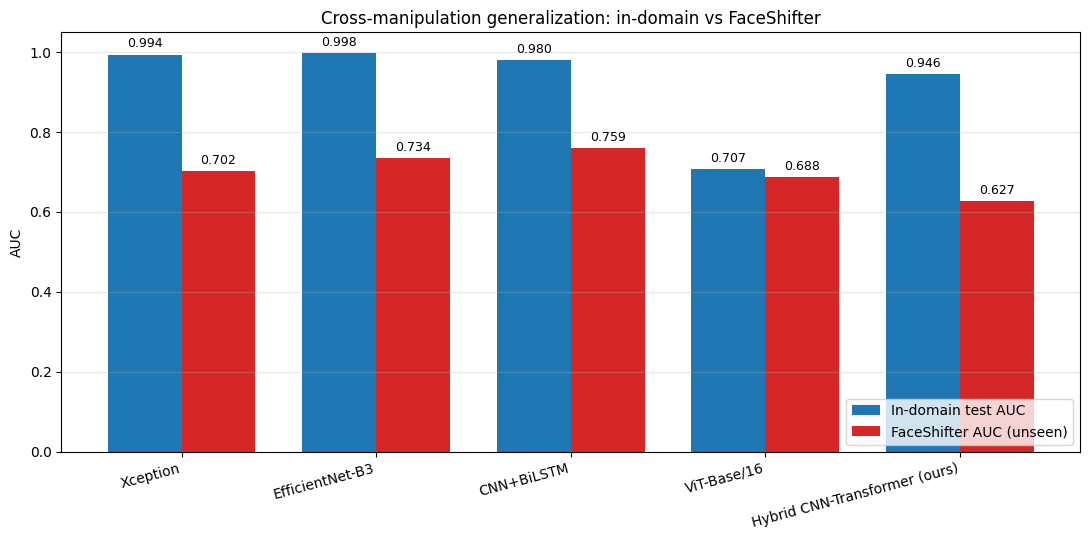

In [21]:
display_labels = [row["display_label"] for row in comparison_rows]
in_domain_aucs = [row["in_domain_test_auc"] for row in comparison_rows]
faceshifter_aucs = [row["faceshifter_auc"] for row in comparison_rows]

x_positions = np.arange(len(display_labels))
bar_width = 0.38

fig, ax = plt.subplots(figsize=(11, 5.5))
bars_in_domain = ax.bar(x_positions - bar_width / 2, in_domain_aucs, bar_width, label="In-domain test AUC", color="C0")
bars_faceshifter = ax.bar(x_positions + bar_width / 2, faceshifter_aucs, bar_width, label="FaceShifter AUC (unseen)", color="C3")

# Put AUC value above each bar
for bars in (bars_in_domain, bars_faceshifter):
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f"{h:.3f}", xy=(bar.get_x() + bar.get_width() / 2, h), xytext=(0, 3),
                    textcoords="offset points", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x_positions)
ax.set_xticklabels(display_labels, rotation=15, ha="right")
ax.set_ylabel("AUC")
ax.set_ylim(0.0, 1.05)
ax.set_title("Cross-manipulation generalization: in-domain vs FaceShifter")
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plot_save_path = output_dir_path / "auc_comparison.png"
plt.savefig(plot_save_path, dpi=120, bbox_inches="tight")
plt.show()


## 10. Per-source breakdown on the combined set

The combined evaluation set contains two "sources": `FaceShifter` (fake) and `original` (real from the test split). We print per-source accuracy for each model so we can spot anything weird, e.g. a model that just predicts everything as fake would have 100% on FaceShifter and 0% on real.

In [22]:
print(f"{'Model':<32} {'FaceShifter acc':>16} {'Real (original) acc':>22}")
print("-" * 72)

for model_name, result in cross_manipulation_results.items():
    predictions = result["faceshifter_predictions"]
    probs_by_class = defaultdict(list)
    labels_by_class = defaultdict(list)
    for probability, true_label, class_name in zip(
        predictions["predicted_probs"],
        predictions["true_labels"],
        predictions["class_names"],
    ):
        probs_by_class[class_name].append(probability)
        labels_by_class[class_name].append(true_label)
    
    per_class_accuracy = {}
    for cls_name in probs_by_class:
        probs = np.array(probs_by_class[cls_name])
        true_labels = np.array(labels_by_class[cls_name])
        predicted = (probs >= 0.5).astype(int)
        per_class_accuracy[cls_name] = (predicted == true_labels).mean()
    
    faceshifter_acc = per_class_accuracy.get("FaceShifter", float("nan"))
    real_acc = per_class_accuracy.get("original", float("nan"))
    print(f"{result['display_label']:<32} {faceshifter_acc:>16.4f} {real_acc:>22.4f}")

Model                             FaceShifter acc    Real (original) acc
------------------------------------------------------------------------
Xception                                   0.1900                 0.9286
EfficientNet-B3                            0.3150                 0.9286
CNN+BiLSTM                                 0.3300                 0.9286
ViT-Base/16                                0.6075                 0.6714
Hybrid CNN-Transformer (ours)              0.2400                 0.9143
